# Problem Statement

In [1]:
# Let's start with importing necessary libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv(r"C:\Users\DELL\Downloads\diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.shape

(768, 9)

In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Data Preprocessing

In [5]:
# replacing zero values with the mean of the column
data['BMI'] = data['BMI'].replace(0,data['BMI'].mean())
data['BloodPressure']= data['BloodPressure'].replace(0,data['BloodPressure'].mean())
data['Glucose'] = data['Glucose'].replace(0,data['Glucose'].mean())
data['Insulin'] = data['Insulin'].replace(0,data['Insulin'].mean())
data['SkinThickness'] = data['SkinThickness'].replace(0,data['SkinThickness'].mean())

In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


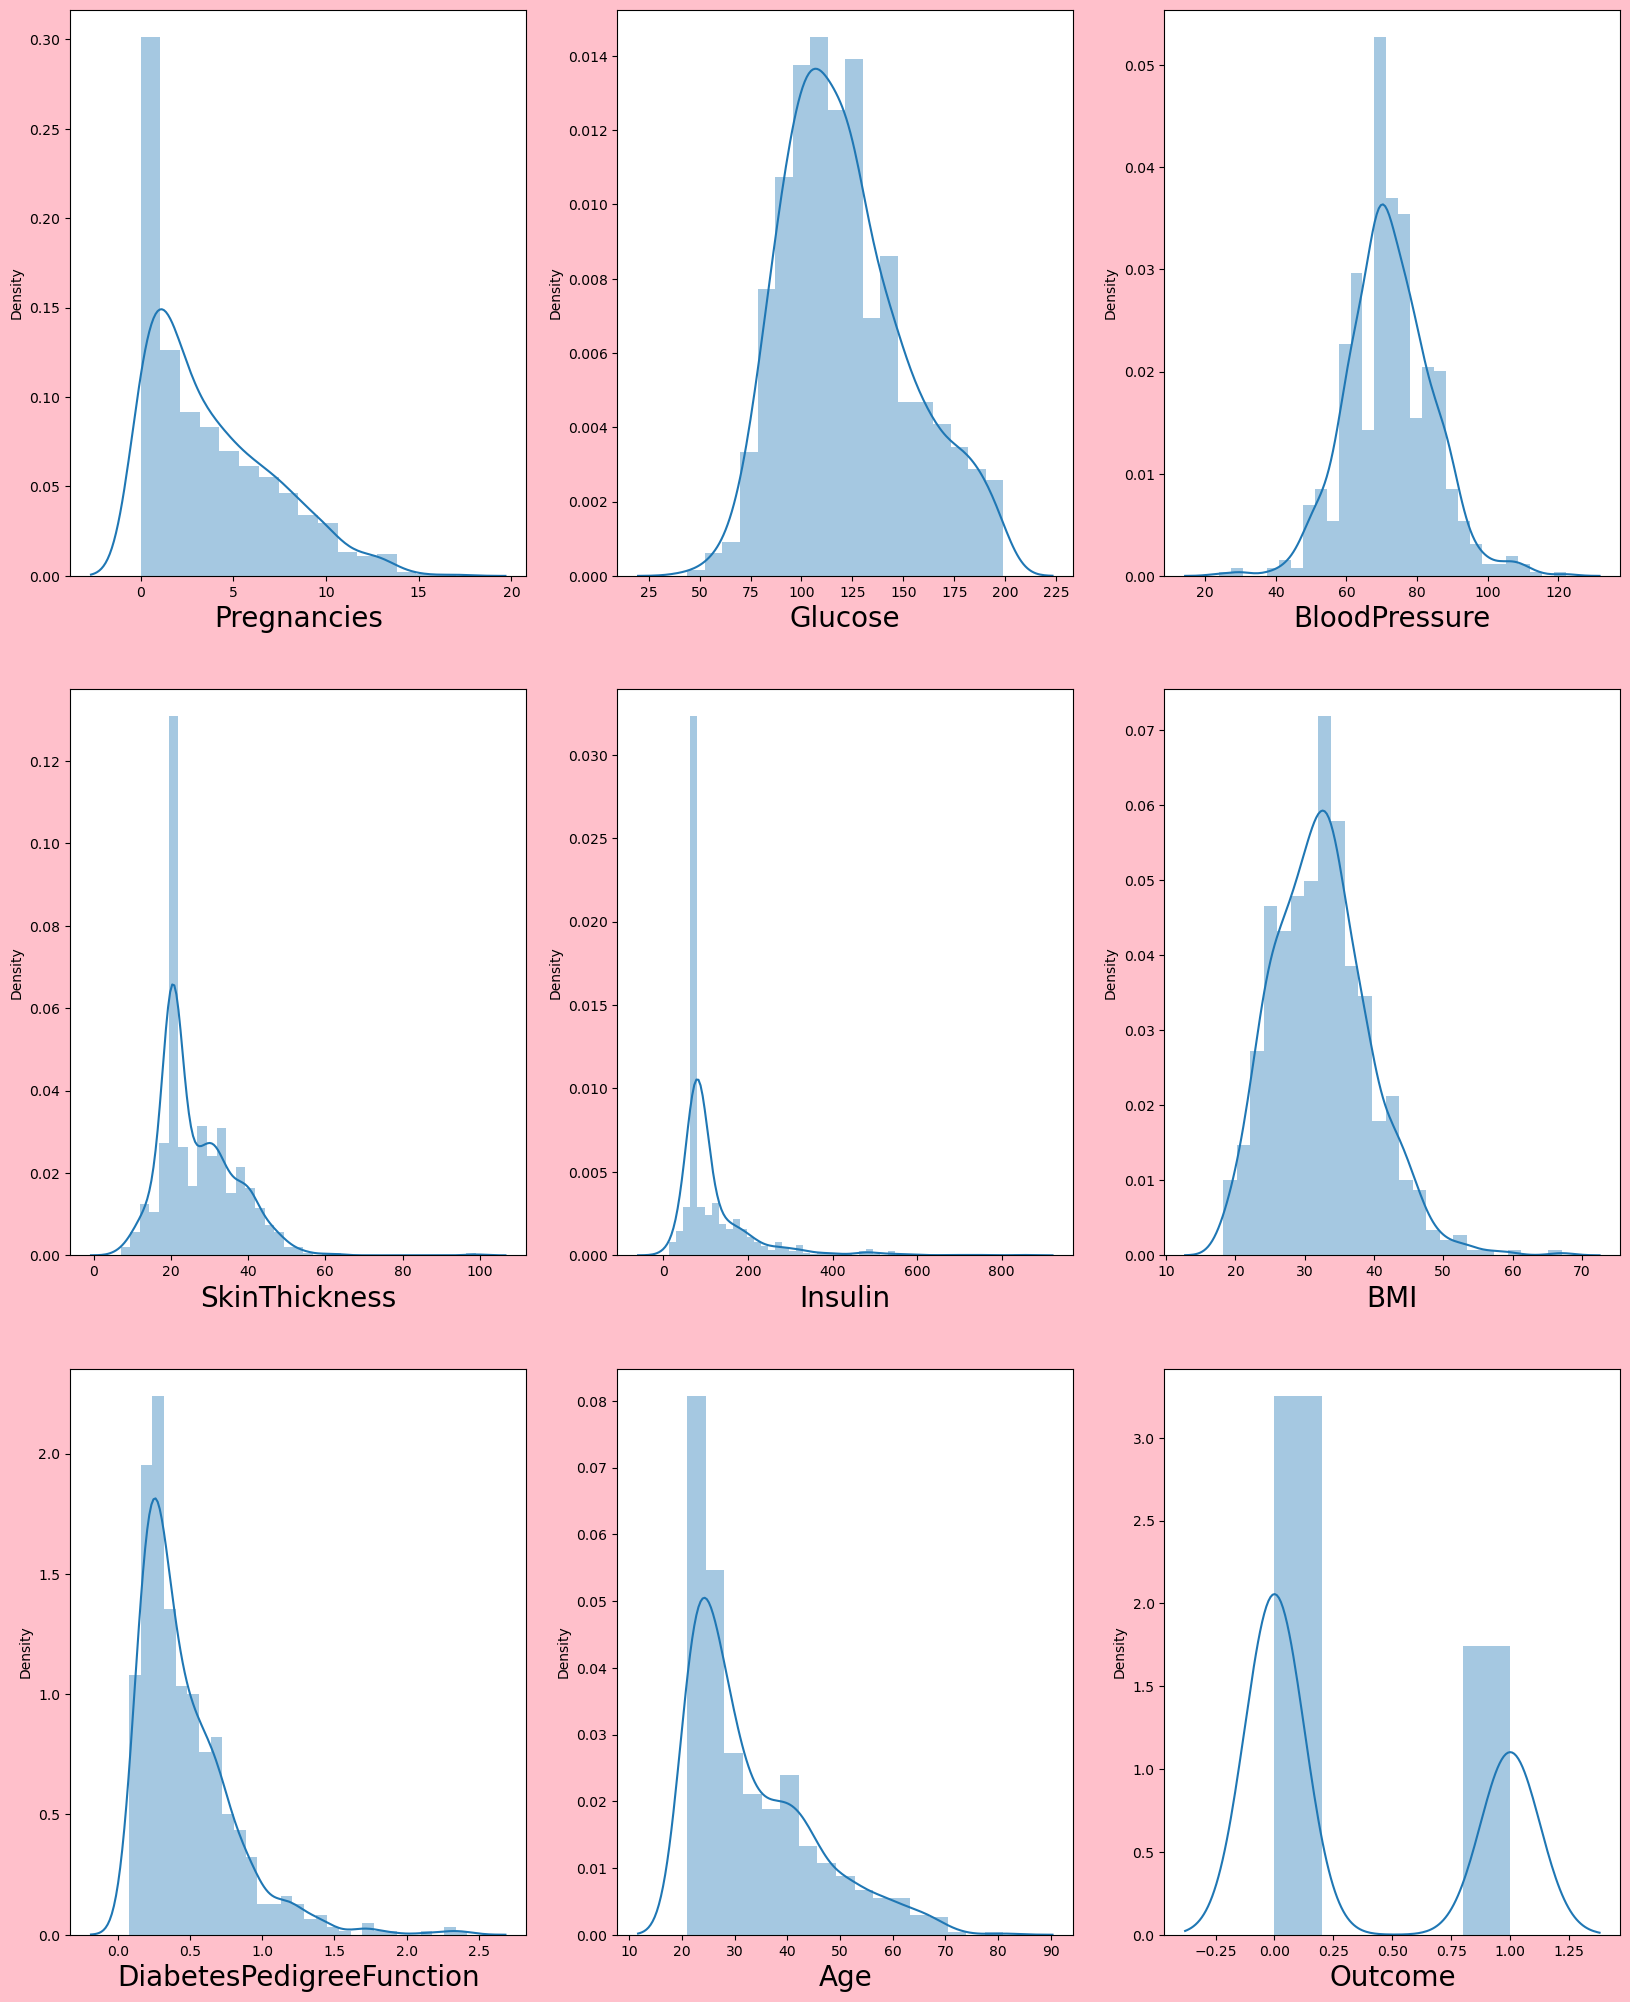

In [7]:
# Let's see how data is distributed for every column
plt.figure(figsize=(20,25),facecolor='Pink')
plotnumber = 1

for column in data:
    if plotnumber<=9 :   # as there are 9 columns in the data
        ax= plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize = 20)

    plotnumber+=1
plt.show()

In [8]:
df_features = data.drop('Outcome',axis=1)

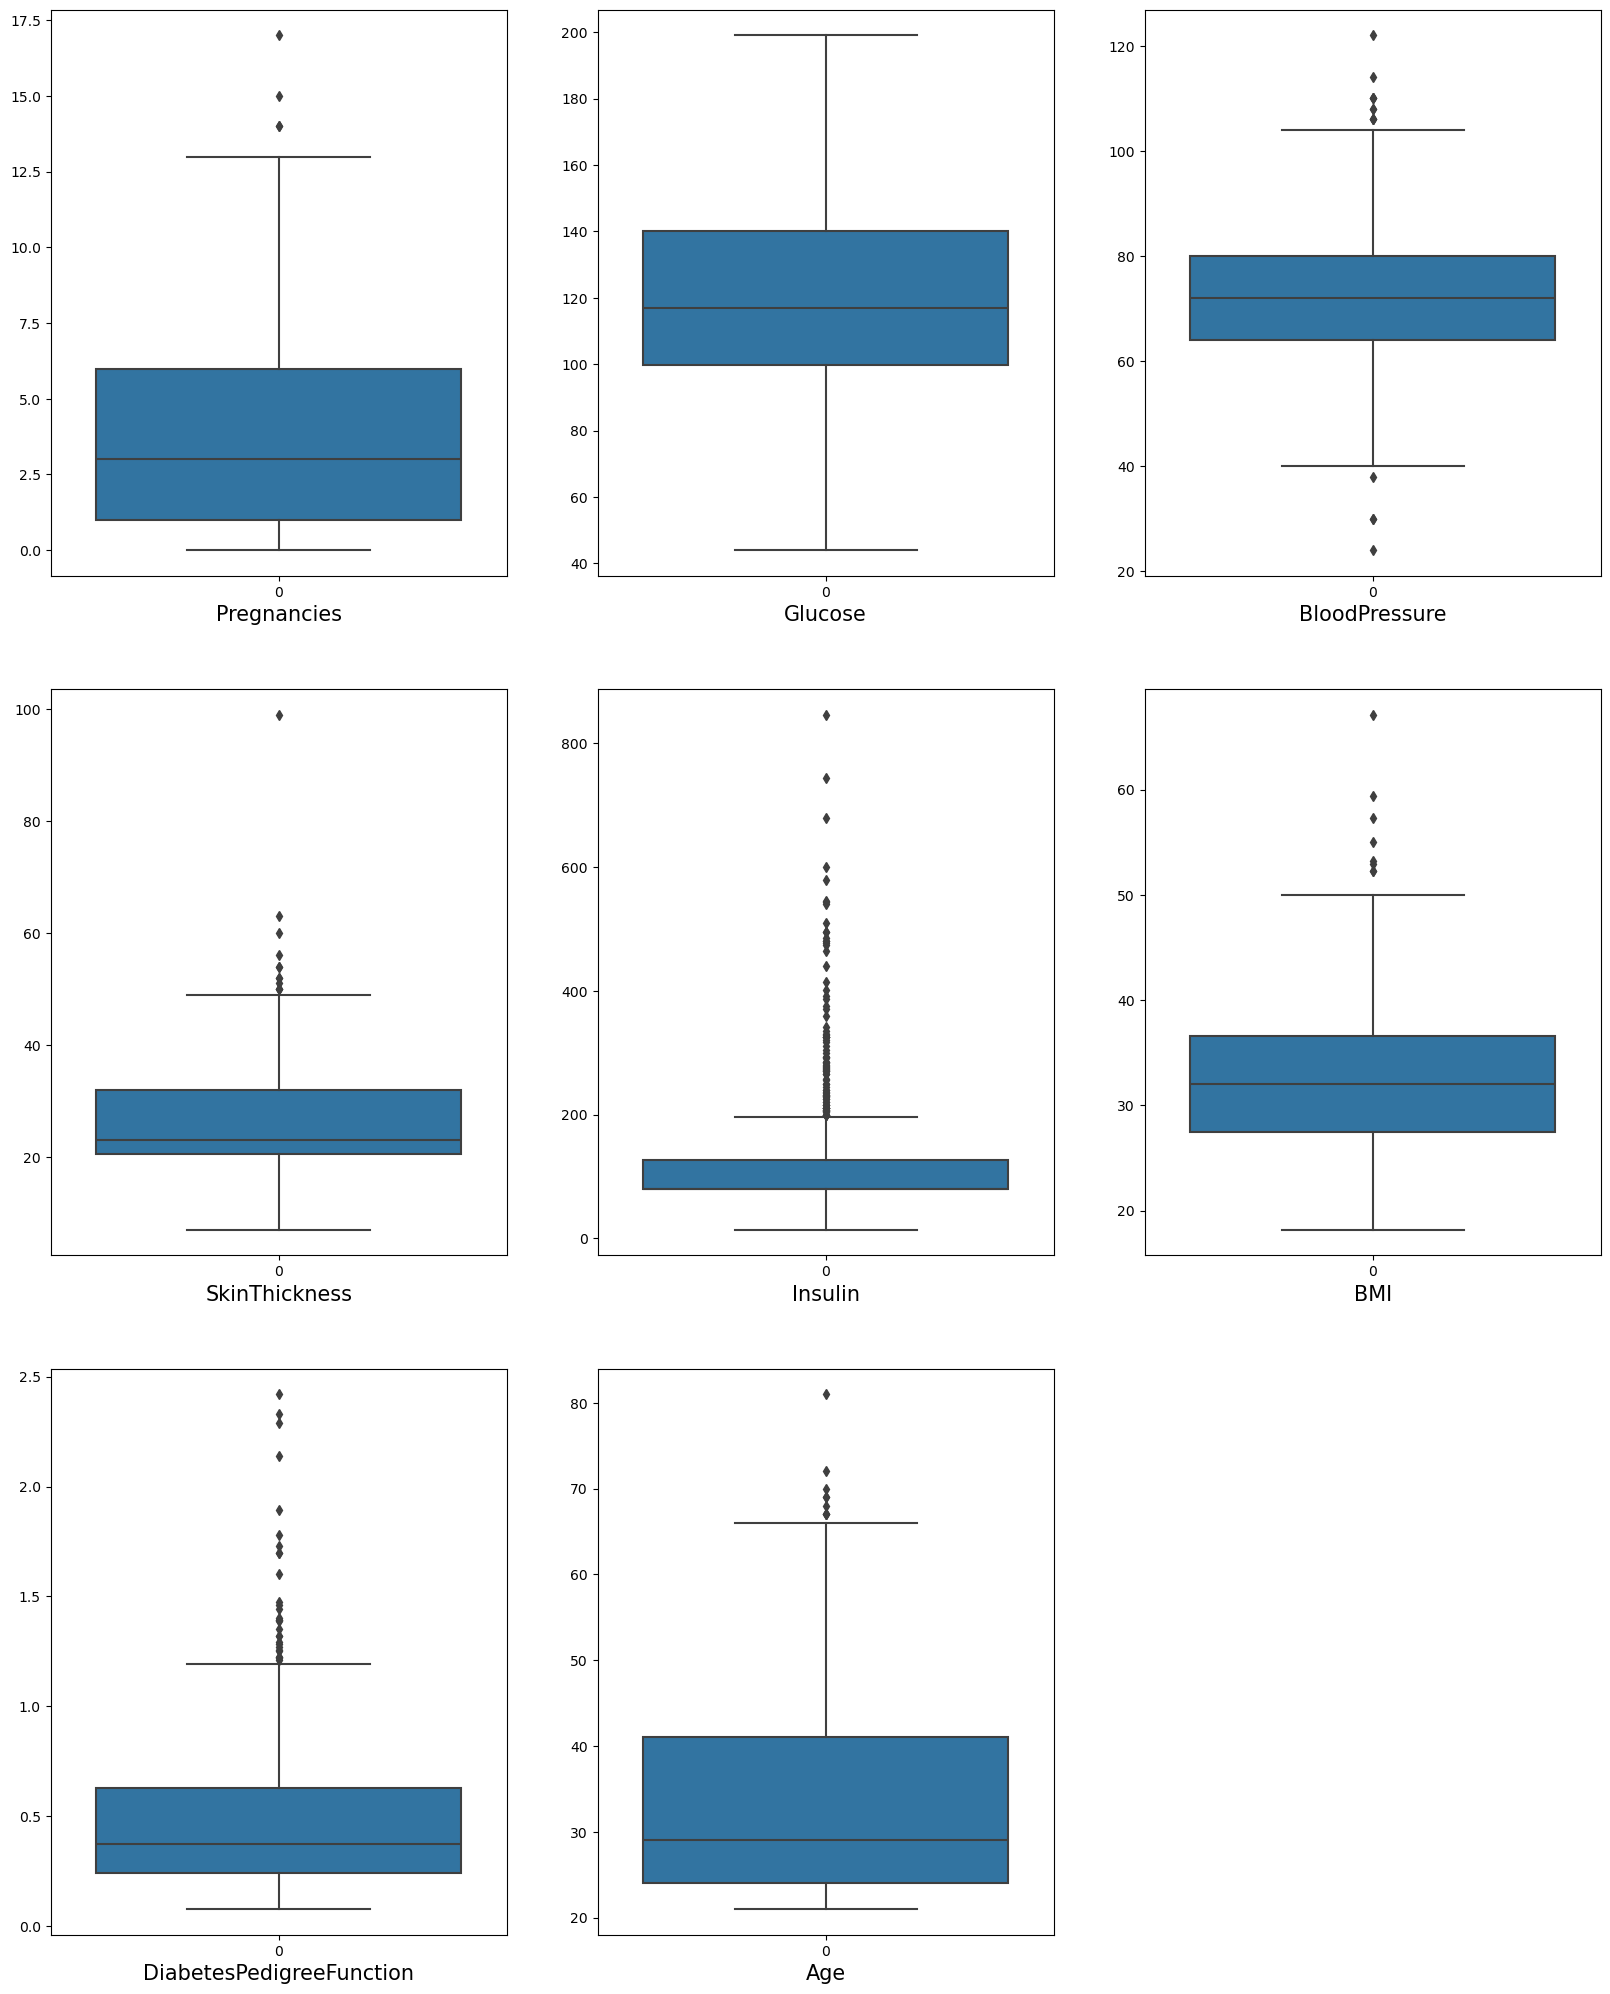

In [9]:
# Visualize the outliers using boxplot
plt.figure(figsize=(20,25))
graph = 1

for column in df_features:
    if graph<=9:
        plt.subplot(3,3,graph)
        ax=sns.boxplot(data=df_features[column])
        plt.xlabel(column,fontsize=15)
    graph+=1

plt.show()

In [10]:
data.shape

(768, 9)

In [11]:
# Find the IQR(inter quantile range) to identify outliers

# 1st quantile
q1 = data.quantile(0.25)

#3rd quantile
q3 = data.quantile(0.75)

#IQR
iqr = q3-q1

In [12]:
q1

Pregnancies                  1.000000
Glucose                     99.750000
BloodPressure               64.000000
SkinThickness               20.536458
Insulin                     79.799479
BMI                         27.500000
DiabetesPedigreeFunction     0.243750
Age                         24.000000
Outcome                      0.000000
Name: 0.25, dtype: float64

# Outlier detection formula
# higher side ==> Q3+(1.5*IQR)
# lower side ==> Q1-(1.5*IQR)

In [13]:
# validating one outlier

preg_high = (q3.Pregnancies + (1.5 * iqr.Pregnancies))
preg_high

13.5

In [14]:
# Check the indexes which have higher values
np_index = np.where(data['Pregnancies']> preg_high)
np_index

(array([ 88, 159, 298, 455], dtype=int64),)

In [15]:
# Drop the index which we found in the above cell
data = data.drop(data.index[np_index])
data.shape

(764, 9)

In [16]:
data.reset_index()

,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
759,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
760,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
761,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
762,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [17]:
bp_high = (q3.BloodPressure + (1.5 * iqr.BloodPressure))
print (bp_high)
index = np.where(data['BloodPressure'] > bp_high)
data = data.drop(data.index[index])
print(data.shape)
data.reset_index()

104.0
(754, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
749,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
750,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
751,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
752,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [18]:
index

(array([ 43,  84, 105, 175, 359, 545, 654, 658, 668, 687], dtype=int64),)

In [19]:
st_high = (q3.SkinThickness + (1.5 * iqr.BloodPressure))
print (bp_high)

104.0


In [20]:
index = np.where(data['BloodPressure']> bp_high)
data = data.drop(data.index[index])
print(data.shape)
data.reset_index()

(754, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
749,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
750,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
751,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
752,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [21]:
insu_high = (q3.Insulin + (1.5 * iqr.Insulin))
print (insu_high)
index = np.where(data['Insulin'] > insu_high)
data = data.drop(data.index[index])
print(data.shape)
data.reset_index()

198.42578125
(667, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
662,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
663,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
664,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
665,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [22]:
bmi_high = (q3.BMI + (1.5 * iqr.BMI))
print (bmi_high)
index = np.where(data['BMI'] > bmi_high)
data = data.drop(data.index[index])
print(data.shape)
data.reset_index()

50.25
(662, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
657,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
658,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
659,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
660,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [23]:
dpf_high = (q3.DiabetesPedigreeFunction + (1.5 * iqr.DiabetesPedigreeFunction))
print (dpf_high)
index = np.where(data['DiabetesPedigreeFunction'] > dpf_high)
data = data.drop(data.index[index])
print(data.shape)
data.reset_index()

1.2
(639, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,5,5,116.0,74.0,20.536458,79.799479,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...,...
634,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
635,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
636,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
637,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [24]:
age_high = (q3.Age + (1.5 * iqr.Age))
print (age_high)
index = np.where(data['Age'] > age_high)
data = data.drop(data.index[index])
print(data.shape)
data.reset_index()

66.5
(630, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,5,5,116.0,74.0,20.536458,79.799479,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...,...
625,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
626,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
627,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
628,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


In [25]:
bp_low = (q3.BloodPressure + (1.5 * iqr.BloodPressure))
print (bp_low)
index = np.where(data['BloodPressure'] > bp_low)
data = data.drop(data.index[index])
print(data.shape)
data.reset_index()

104.0
(630, 9)


,index,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,5,5,116.0,74.0,20.536458,79.799479,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...,...
625,763,10,101.0,76.0,48.000000,180.000000,32.9,0.171,63,0
626,764,2,122.0,70.0,27.000000,79.799479,36.8,0.340,27,0
627,765,5,121.0,72.0,23.000000,112.000000,26.2,0.245,30,0
628,766,1,126.0,60.0,20.536458,79.799479,30.1,0.349,47,1


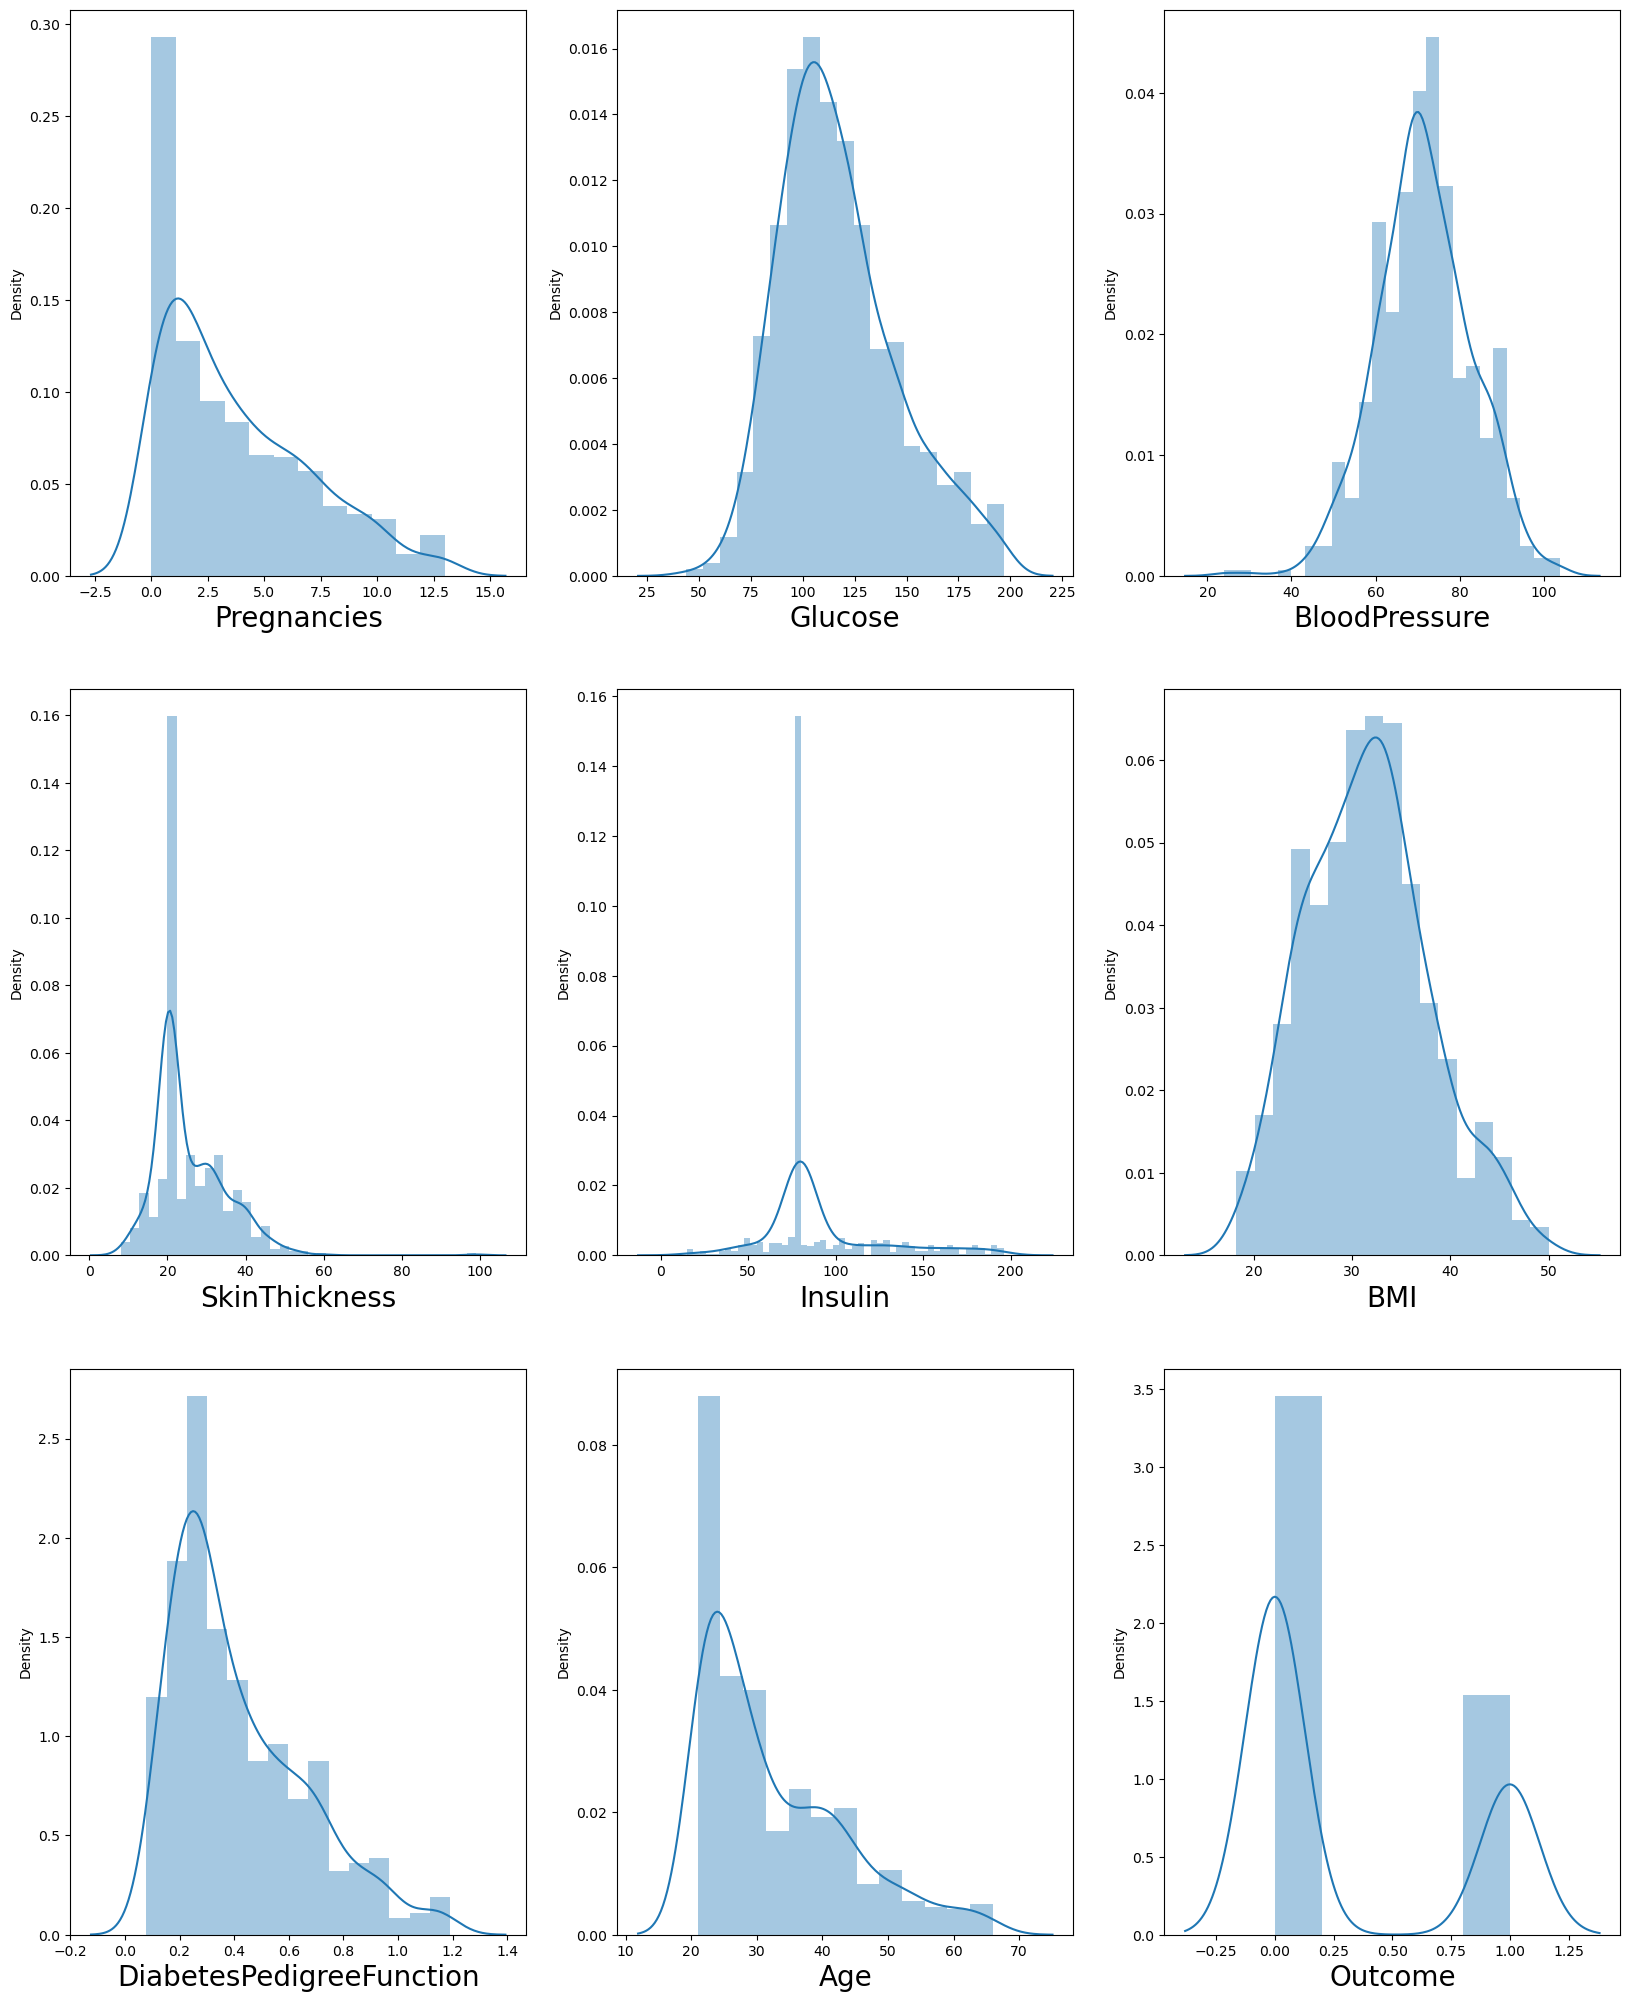

In [26]:
plt.figure(figsize=(20,25))
plotnumber = 1

for column in data:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)

    plotnumber+=1
plt.show()
        

# finding relationship. We want to keep only those features which have relationship with label.

In [27]:
x= data.drop(columns=['Outcome'])
y=data['Outcome']

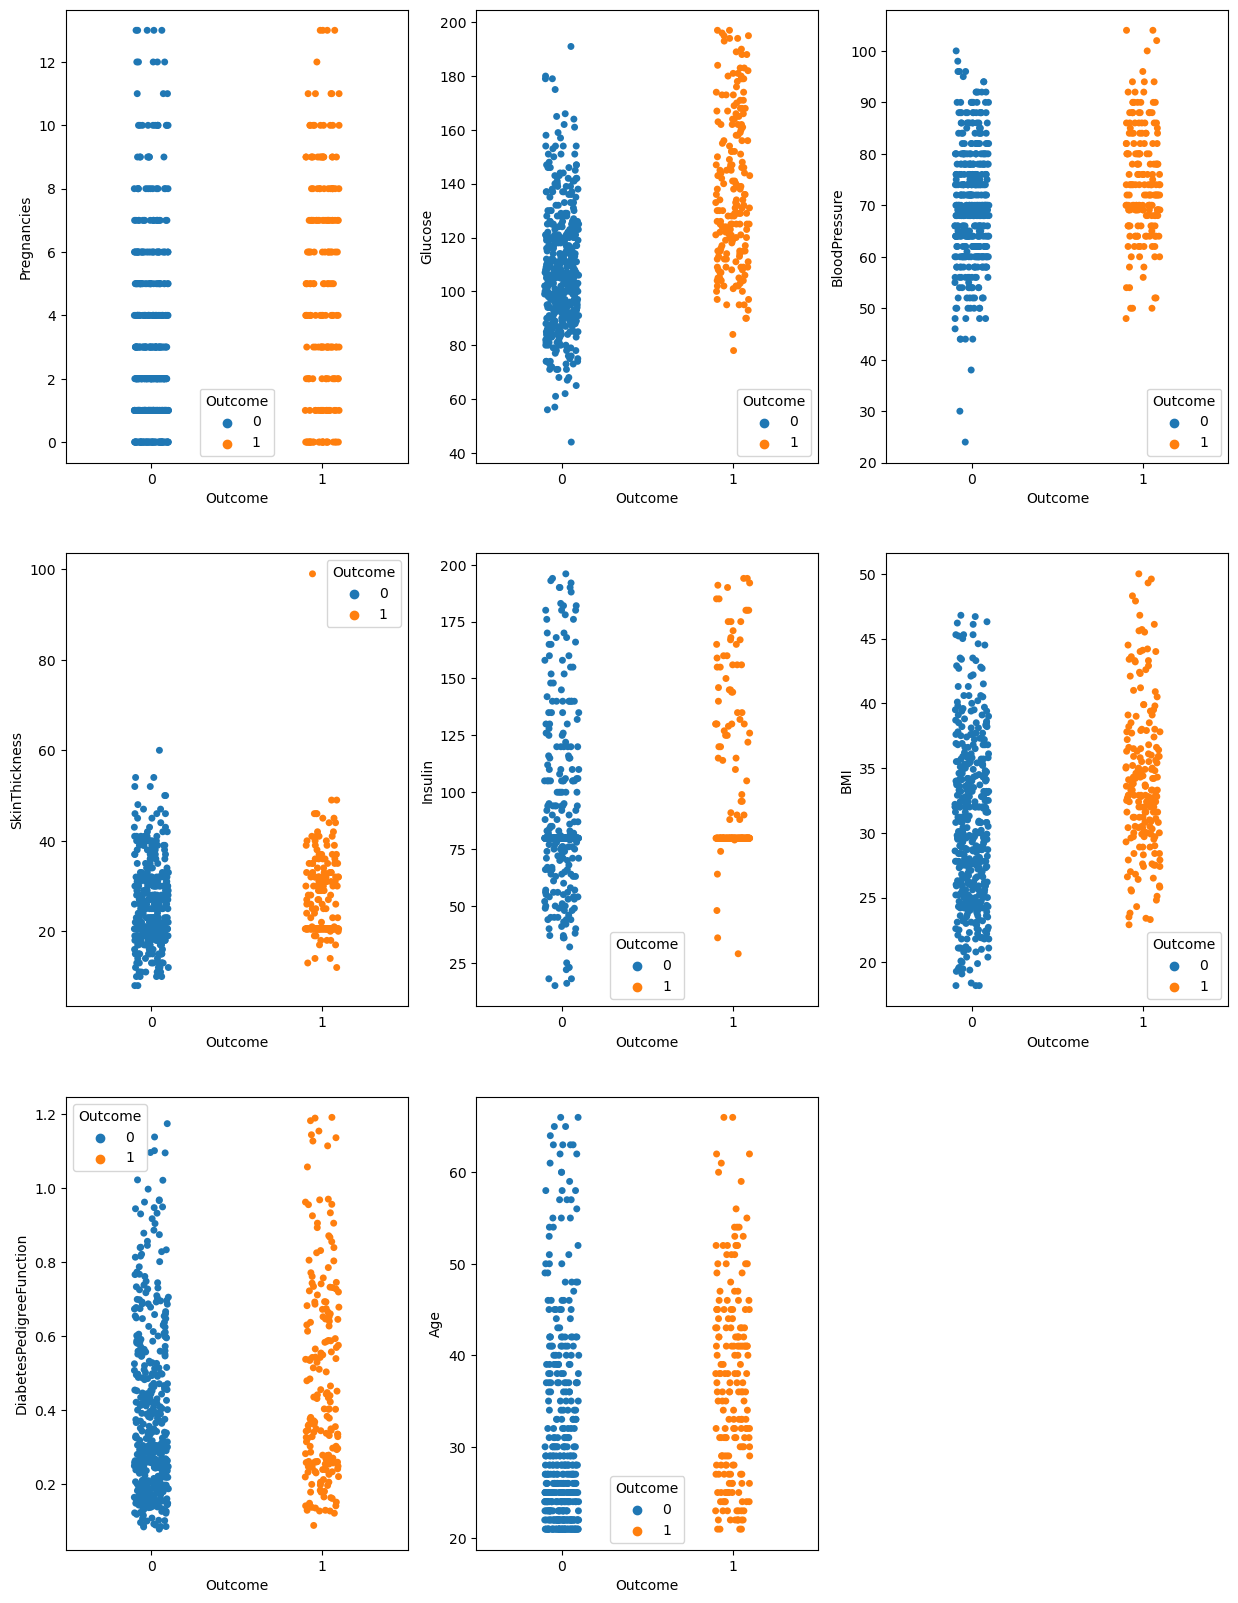

In [28]:
# Let's see how features are related to class.
plt.figure(figsize=(15,20))
plotnumber=1

for column in x:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.stripplot(x=y,y=x[column],hue=y)
    plotnumber+=1
plt.show()
                      
        

# Check multicollinearity problem. Find if one feature is dependent on another feature.


In [29]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)

In [30]:
x_scaled.shape[1]

8

In [31]:
# Finding variance inflation factor in each scaled column i.e x_scaled.shape[1] (1/(1-R2))

In [32]:
vif =pd.DataFrame()
vif["vif"]= [variance_inflation_factor(x_scaled,i) for i in range(x_scaled.shape[1])]
vif["Features"] = x.columns

# Let's check the values
vif

,vif,Features
0,1.435509,Pregnancies
1,1.247834,Glucose
2,1.240860,BloodPressure
3,1.370029,SkinThickness
4,1.165233,Insulin
5,1.433122,BMI
6,1.038023,DiabetesPedigreeFunction
7,1.649890,Age


In [33]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size= 0.25, random_state= 355)

# Pre-processing steps completed

# Model building

In [34]:
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [35]:
y_pred = log_reg.predict(x_test)

In [36]:
y_pred

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0], dtype=int64)

In [37]:
log_reg.predict_proba(x_test)

array([[0.64791322, 0.35208678],
       [0.31376166, 0.68623834],
       [0.7106231 , 0.2893769 ],
       [0.89306972, 0.10693028],
       [0.97792755, 0.02207245],
       [0.98988338, 0.01011662],
       [0.81880663, 0.18119337],
       [0.37638277, 0.62361723],
       [0.99340231, 0.00659769],
       [0.94676717, 0.05323283],
       [0.85595821, 0.14404179],
       [0.97411353, 0.02588647],
       [0.93481441, 0.06518559],
       [0.55487262, 0.44512738],
       [0.7546846 , 0.2453154 ],
       [0.94282858, 0.05717142],
       [0.81935907, 0.18064093],
       [0.68327393, 0.31672607],
       [0.19435996, 0.80564004],
       [0.43484985, 0.56515015],
       [0.26930365, 0.73069635],
       [0.40831558, 0.59168442],
       [0.57807288, 0.42192712],
       [0.49728063, 0.50271937],
       [0.86324616, 0.13675384],
       [0.84267541, 0.15732459],
       [0.19010434, 0.80989566],
       [0.88736331, 0.11263669],
       [0.9576008 , 0.0423992 ],
       [0.97453887, 0.02546113],
       [0.

In [38]:
# Confusion Matrix
conf_mat = confusion_matrix(y_test,y_pred)
conf_mat

array([[96, 12],
       [24, 26]], dtype=int64)

In [39]:
# Model Accuracy
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.7721518987341772

In [ ]:
#Let's check Accuracy manually
Accuracy = (TP+TN)
           ___________
           (TP+TN+FP+FN)


In [42]:
(94+24)/(94+24+11+26)

0.7612903225806451

# Similarly you can manually calculate recall/precision/F1 score

In [44]:
from sklearn.metrics import classification_report

In [45]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       108
           1       0.68      0.52      0.59        50

    accuracy                           0.77       158
   macro avg       0.74      0.70      0.72       158
weighted avg       0.76      0.77      0.76       158



In [46]:
# ROC curve
fpr,tpr, thresholds = roc_curve(y_test, y_pred)

In [47]:
# thresholds[0] means no instances predicted (It should be read from 0 -max)
print ('Threshold = ', thresholds)
print ('True Positive rate = ',tpr)
print ('False Positive rate = ',fpr)


Threshold =  [2 1 0]
True Positive rate =  [0.   0.52 1.  ]
False Positive rate =  [0.         0.11111111 1.        ]


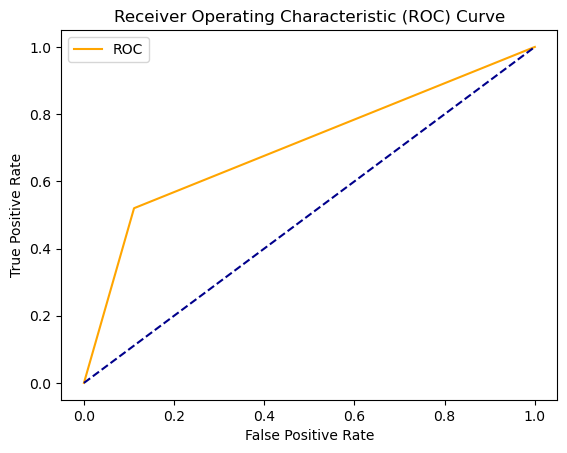

In [49]:
plt.plot(fpr,tpr,color='Orange',label='ROC')
plt.plot([0,1],[0,1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()